 # Step 1 — Import libraries and load the dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load files according to the row counts you verified
train = pd.read_csv("UNSW_NB15_testing-set.csv")
test = pd.read_csv("UNSW_NB15_training-set.csv")

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

display(train.head())

Training shape: (175341, 45)
Testing shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


# Step 2 — Data preprocessing

In [5]:
print("Missing values in training:", train.isnull().sum().sum())
print("Duplicate training rows:", train.duplicated().sum())

print("\nColumn data types:")
print(train.dtypes)

print("\nTarget labels:")
print(train["attack_cat"].value_counts())

Missing values in training: 0
Duplicate training rows: 0

Column data types:
id                     int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             i

In [6]:
train = train.drop_duplicates().copy()

# Remove rows without a target category
train = train.dropna(subset=["attack_cat", "label"]).copy()

print("Training shape after cleaning:", train.shape)

Training shape after cleaning: (175341, 45)


# Step 3 — Analyze attack distribution

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


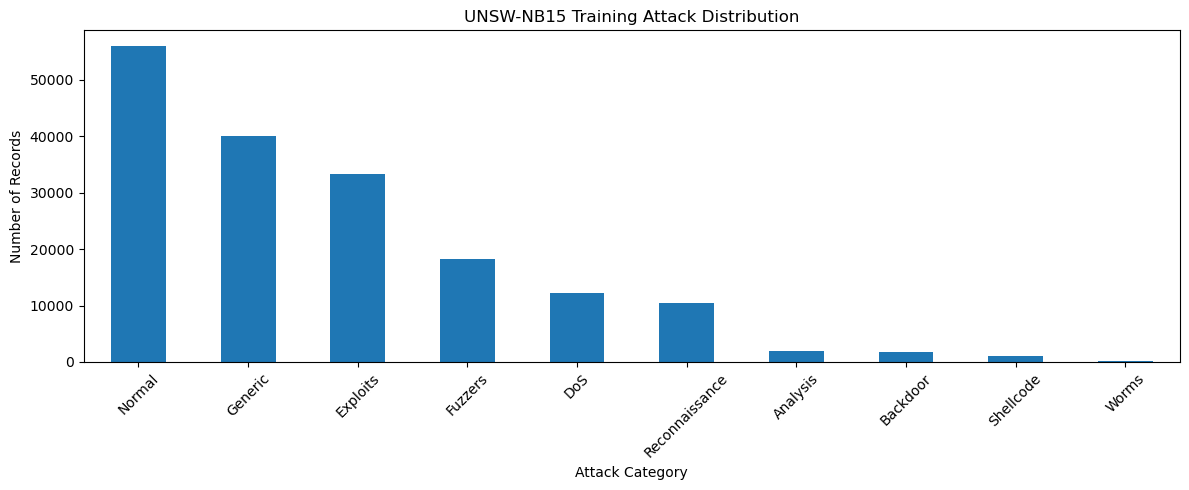

In [7]:
attack_counts = train["attack_cat"].value_counts()

print(attack_counts)

plt.figure(figsize=(12, 5))
attack_counts.plot(kind="bar")
plt.title("UNSW-NB15 Training Attack Distribution")
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Identify the rarest attack automatically:
minority_attack = attack_counts.idxmin()
minority_count = attack_counts.min()

print("Rarest attack:", minority_attack)
print("Number of records:", minority_count)

Rarest attack: Worms
Number of records: 130


# Step 4 — Install and import CTGAN

In [9]:
%pip install sdv

   ---------------------------------------- 0.0/16.0 MB ? eta -:--:--
   -- ------------------------------------- 1.0/16.0 MB 6.9 MB/s eta 0:00:03
   ------ --------------------------------- 2.6/16.0 MB 6.3 MB/s eta 0:00:03
   --------- ------------------------------ 3.9/16.0 MB 6.3 MB/s eta 0:00:02
   ------------ --------------------------- 5.0/16.0 MB 6.1 MB/s eta 0:00:02
   --------------- ------------------------ 6.0/16.0 MB 5.6 MB/s eta 0:00:02
   ----------------- ---------------------- 7.1/16.0 MB 5.6 MB/s eta 0:00:02
   -------------------- ------------------- 8.4/16.0 MB 5.5 MB/s eta 0:00:02
   ------------------------ --------------- 9.7/16.0 MB 5.6 MB/s eta 0:00:02
   ---------------------------- ----------- 11.3/16.0 MB 5.8 MB/s eta 0:00:01
   ------------------------------ --------- 12.3/16.0 MB 5.8 MB/s eta 0:00:01
   ---------------------------------- ----- 13.6/16.0 MB 5.8 MB/s eta 0:00:01
   ------------------------------------- -- 14.9/16.0 MB 5.8 MB/s eta 0:00:01
  

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 2.25.0 requires botocore<1.40.50,>=1.40.46, but you have botocore 1.43.111 which is incompatible.


In [10]:
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

# Step 5 — Prepare the rare attack data and train CTGAN

In [31]:
# Step 5: Prepare rare attack data for CTGAN
rare_data = train[
    train["attack_cat"] == minority_attack
].copy()

drop_columns = ["id", "attack_cat", "label"]

ctgan_data = rare_data.drop(
    columns=drop_columns
).copy()

# Determine numeric columns from the original training schema
numeric_cols = [
    col for col in ctgan_data.columns
    if pd.api.types.is_numeric_dtype(train[col])
]

categorical_cols = [
    col for col in ctgan_data.columns
    if col not in numeric_cols
]

# Preserve numeric feature types
for col in numeric_cols:
    ctgan_data[col] = pd.to_numeric(
        ctgan_data[col], errors="coerce"
    )

# Preserve categorical feature types
for col in categorical_cols:
    ctgan_data[col] = (
        ctgan_data[col].fillna("Unknown").astype(str)
    )

# Replace infinite values and remove incomplete records
ctgan_data = ctgan_data.replace(
    [np.inf, -np.inf], np.nan
).dropna().copy()

print("Records for CTGAN:", ctgan_data.shape)
print("ct_state_ttl dtype:", ctgan_data["ct_state_ttl"].dtype)
print("ct_state_ttl values:")
print(ctgan_data["ct_state_ttl"].value_counts())

print("\nNumeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))


Records for CTGAN: (130, 42)
ct_state_ttl dtype: int64
ct_state_ttl values:
ct_state_ttl
1    113
2     15
0      2
Name: count, dtype: int64

Numeric columns: 39
Categorical columns: 3


In [39]:
metadata.update_column(
    column_name="state",
    sdtype="categorical"
)

metadata.update_column(
    column_name="ct_state_ttl",
    sdtype="numerical"
)

# Train CTGAN using corrected metadata
synthesizer = CTGANSynthesizer(
    metadata,
    epochs=50,
    batch_size=50,
    verbose=True
)

synthesizer.fit(ctgan_data)

print("CTGAN training completed.")


C:\Users\HP\anaconda3\Lib\site-packages\sdv\single_table\base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
C:\Users\HP\anaconda3\Lib\site-packages\sdv\single_table\base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-00.92) | Discrim. (+00.20): 100%|███████████████████████████████████████████████| 50/50 [00:07<00:00,  6.92it/s]

CTGAN training completed.


# Step 6 — Generate synthetic rare samples

In [42]:
synthetic_data = synthesizer.sample(num_rows=500)

synthetic_data["attack_cat"] = minority_attack
synthetic_data["label"] = 1

print("Synthetic data shape:", synthetic_data.shape)

print("\nct_state_ttl values:")
print(synthetic_data["ct_state_ttl"].value_counts(dropna=False))

print("\nct_state_ttl type:")
print(synthetic_data["ct_state_ttl"].dtype)

display(synthetic_data.head())


Synthetic data shape: (500, 44)

ct_state_ttl values:
ct_state_ttl
1    410
2     80
0     10
Name: count, dtype: int64

ct_state_ttl type:
int64


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,11.482953,tcp,http,FIN,18,12,92,28753,1.070035,254,...,1,1,0,0,1,4,1,0,Worms,1
1,1.314405,tcp,http,FIN,116,0,92,30448,678.649677,254,...,1,1,0,0,1,3,2,0,Worms,1
2,3.912711,tcp,http,FIN,13,0,274,0,1.070035,254,...,1,1,0,0,1,3,1,0,Worms,1
3,8.424536,tcp,http,FIN,22,0,92,39408,1044.535550,254,...,1,1,0,0,1,3,1,0,Worms,1
4,1.402067,tcp,http,INT,20,0,92,0,1.070035,254,...,1,1,0,0,1,3,2,0,Worms,1


# Step 7 — Validate synthetic data

In [43]:
# Select numeric columns from the original CTGAN training data
numeric_cols = ctgan_data.select_dtypes(
    include=np.number
).columns.tolist()

# Convert both datasets' selected columns to numeric safely
real_numeric = ctgan_data[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

synthetic_numeric = synthetic_data[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

# Compare real and synthetic statistics
comparison = pd.DataFrame({
    "Real Mean": real_numeric.mean(),
    "Synthetic Mean": synthetic_numeric.mean(),
    "Real Std": real_numeric.std(),
    "Synthetic Std": synthetic_numeric.std()
})

display(comparison.round(3))

,Real Mean,Synthetic Mean,Real Std,Synthetic Std
dur,1.429000e+00,4.036000e+00,2.316000e+00,3.933000e+00
spkts,1.870800e+01,2.502000e+01,2.454400e+01,2.614200e+01
dpkts,6.483100e+01,5.815600e+01,1.546320e+02,1.410680e+02
sbytes,2.403438e+03,4.807300e+02,6.926380e+03,1.117721e+03
dbytes,7.968168e+04,4.187476e+04,2.079066e+05,9.530369e+04
rate,2.085749e+04,8.939455e+03,7.005720e+04,4.109142e+04
sttl,2.480920e+02,2.509280e+02,3.328500e+01,2.411500e+01
dttl,2.229230e+02,2.056320e+02,8.082200e+01,9.774400e+01
sload,7.375536e+07,2.843470e+08,2.897796e+08,5.359505e+08
dload,1.297531e+05,8.002229e+04,2.933175e+05,2.087733e+05


In [45]:
# Additional Step 7 validation

print("Synthetic rows:", len(synthetic_data))

print(
    "Missing numeric values:",
    synthetic_numeric.isna().sum().sum()
)

print(
    "Infinite numeric values:",
    np.isinf(synthetic_numeric).sum().sum()
)

# Check whether synthetic numerical values fall within real-data ranges
range_check = pd.DataFrame({
    "Real Min": real_numeric.min(),
    "Synthetic Min": synthetic_numeric.min(),
    "Real Max": real_numeric.max(),
    "Synthetic Max": synthetic_numeric.max()
})

display(range_check.round(3))

Synthetic rows: 500
Missing numeric values: 0
Infinite numeric values: 0


,Real Min,Synthetic Min,Real Max,Synthetic Max
dur,0.000,0.000,1.588700e+01,1.588700e+01
spkts,2.000,2.000,1.160000e+02,1.160000e+02
dpkts,0.000,0.000,6.980000e+02,6.980000e+02
sbytes,92.000,92.000,7.848100e+04,1.799100e+04
dbytes,0.000,0.000,9.153020e+05,9.153020e+05
rate,1.070,1.070,5.000000e+05,5.000000e+05
sttl,62.000,62.000,2.540000e+02,2.540000e+02
dttl,0.000,0.000,2.520000e+02,2.520000e+02
sload,585.624,585.624,1.640000e+09,1.640000e+09
dload,0.000,0.000,1.178738e+06,1.178738e+06


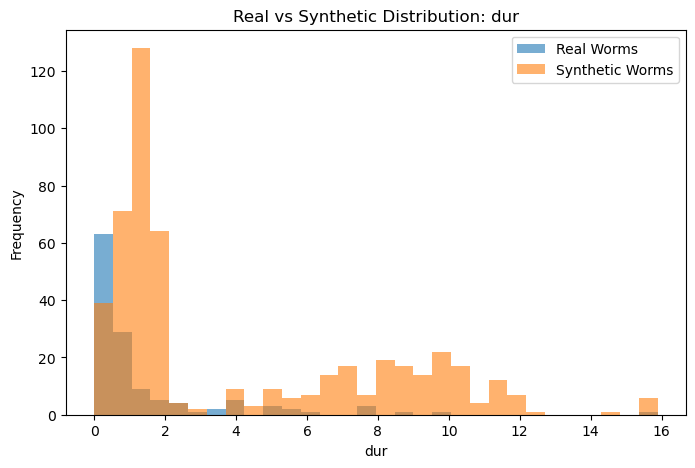

In [46]:
# plot a numerical feature
feature = "dur"

plt.figure(figsize=(8, 5))

plt.hist(
    pd.to_numeric(ctgan_data[feature], errors="coerce").dropna(),
    bins=30,
    alpha=0.6,
    label="Real Worms"
)

plt.hist(
    pd.to_numeric(synthetic_data[feature], errors="coerce").dropna(),
    bins=30,
    alpha=0.6,
    label="Synthetic Worms"
)

plt.title(f"Real vs Synthetic Distribution: {feature}")
plt.xlabel(feature)
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Step 8 — Prepare real-only and augmented datasets

In [47]:
# Step 8: Prepare real-only and augmented datasets

feature_columns = [
    col for col in train.columns
    if col not in ["id", "attack_cat", "label"]
]

# Create synthetic records with the original training schema
synthetic_full = synthetic_data.reindex(
    columns=train.columns.drop("id"),
    fill_value=np.nan
).copy()

synthetic_full["attack_cat"] = minority_attack
synthetic_full["label"] = 1
synthetic_full["id"] = np.nan

# Match original column order
synthetic_full = synthetic_full.reindex(columns=train.columns)

# Original training data
real_train = train.copy()

# Combine real and synthetic records
augmented_train = pd.concat(
    [real_train, synthetic_full],
    ignore_index=True
)

print("Real training rows:", len(real_train))
print("Synthetic rows:", len(synthetic_full))
print("Augmented training rows:", len(augmented_train))

Real training rows: 175341
Synthetic rows: 500
Augmented training rows: 175841


# Step 9 — Train two Random Forest classifiers

In [48]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Features only: exclude ID and target columns
feature_columns = [
    c for c in train.columns
    if c not in ["id", "attack_cat", "label"]
]

# Convert synthetic columns to the original training data types
synthetic_full = synthetic_full[train.columns].copy()

for col in feature_columns:
    if col in categorical_features:
        synthetic_full[col] = synthetic_full[col].astype("object")
    else:
        synthetic_full[col] = pd.to_numeric(
            synthetic_full[col], errors="coerce"
        )

# Prepare datasets
real_train = train.copy()

augmented_train = pd.concat(
    [real_train, synthetic_full],
    ignore_index=True
)

X_train = real_train[feature_columns]
y_train = real_train["attack_cat"]

X_aug = augmented_train[feature_columns]
y_aug = augmented_train["attack_cat"]

X_test = test[feature_columns]
y_test = test["attack_cat"]

# Determine column types from the original training data
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = [
    c for c in feature_columns
    if c not in categorical_features
]

def build_model():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessing = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

    return Pipeline([
        ("preprocessing", preprocessing),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ])

# Train both models
model_real = build_model()
model_augmented = build_model()

model_real.fit(X_train, y_train)
model_augmented.fit(X_aug, y_aug)

print("Both classifiers trained successfully!")
print("Real training rows:", len(X_train))
print("Augmented training rows:", len(X_aug))


Both classifiers trained successfully!
Real training rows: 175341
Augmented training rows: 175841


# Step 10 — Compare model performance

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pred_real = model_real.predict(X_test)
pred_aug = model_augmented.predict(X_test)

print("REAL-ONLY MODEL")
print(classification_report(y_test, pred_real, zero_division=0))

print("REAL + SYNTHETIC MODEL")
print(classification_report(y_test, pred_aug, zero_division=0))

REAL-ONLY MODEL
                precision    recall  f1-score   support

      Analysis       0.05      0.09      0.06       677
      Backdoor       0.04      0.29      0.06       583
           DoS       0.31      0.20      0.24      4089
      Exploits       0.73      0.67      0.70     11132
       Fuzzers       0.30      0.57      0.39      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.95      0.77      0.85     37000
Reconnaissance       0.91      0.79      0.85      3496
     Shellcode       0.42      0.65      0.51       378
         Worms       0.56      0.11      0.19        44

      accuracy                           0.75     82332
     macro avg       0.53      0.51      0.48     82332
  weighted avg       0.83      0.75      0.78     82332

REAL + SYNTHETIC MODEL
                precision    recall  f1-score   support

      Analysis       0.01      0.01      0.01       677
      Backdoor       0.04      0.32      0.07       583
     

In [50]:
# Compare Worms attack detection

from sklearn.metrics import confusion_matrix
import pandas as pd

labels = sorted(y_test.unique())

cm_real = confusion_matrix(y_test, pred_real, labels=labels)
cm_aug = confusion_matrix(y_test, pred_aug, labels=labels)

worms_index = labels.index("Worms")

worms_summary = pd.DataFrame({
    "Model": ["Real Only", "Real + Synthetic"],
    "Actual Worms": [
        int((y_test == "Worms").sum()),
        int((y_test == "Worms").sum())
    ],
    "Worms correctly detected": [
        int(cm_real[worms_index, worms_index]),
        int(cm_aug[worms_index, worms_index])
    ]
})

display(worms_summary)

,Model,Actual Worms,Worms correctly detected
0,Real Only,44,5
1,Real + Synthetic,44,7


In [51]:
# Compare overall metrics:
def evaluate_model(name, y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1
    }

results = pd.DataFrame([
    evaluate_model("Real Only", y_test, pred_real),
    evaluate_model("Real + Synthetic", y_test, pred_aug)
])

display(results.round(4))

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Real Only,0.7481,0.5255,0.5113,0.4838
1,Real + Synthetic,0.7483,0.5079,0.5126,0.4808


In [23]:
# calculate how many Worms samples each model detects.
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

def worms_results(name, y_true, y_pred):
    mask = y_true == "Worms"
    actual = y_true[mask]
    predicted = y_pred[mask]

    precision, recall, f1, _ = precision_recall_fscore_support(
        actual,
        predicted,
        labels=["Worms"],
        average="macro",
        zero_division=0
    )

    return {
        "Model": name,
        "Worms test samples": len(actual),
        "Worms correctly detected": int((predicted == "Worms").sum()),
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

worms_comparison = pd.DataFrame([
    worms_results("Real Only", y_test, pred_real),
    worms_results("Real + Synthetic", y_test, pred_aug)
])

display(worms_comparison.round(4))

,Model,Worms test samples,Worms correctly detected,Precision,Recall,F1-score
0,Real Only,44,5,1.0,0.1136,0.2041
1,Real + Synthetic,44,4,1.0,0.0909,0.1667


# Step 11: Additional synthetic data validation

In [24]:
numeric_cols = ctgan_data.select_dtypes(
    include=np.number
).columns

real_num = ctgan_data[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

synthetic_num = synthetic_data[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

validation = pd.DataFrame({
    "Real Missing": real_num.isna().sum(),
    "Synthetic Missing": synthetic_num.isna().sum(),
    "Real Min": real_num.min(),
    "Synthetic Min": synthetic_num.min(),
    "Real Max": real_num.max(),
    "Synthetic Max": synthetic_num.max()
})

display(validation.round(3))

,Real Missing,Synthetic Missing,Real Min,Synthetic Min,Real Max,Synthetic Max
dur,0,0,0.000,0.000,1.588700e+01,1.213400e+01
spkts,0,0,2.000,2.000,1.160000e+02,1.160000e+02
dpkts,0,0,0.000,0.000,6.980000e+02,6.980000e+02
sbytes,0,0,92.000,92.000,7.848100e+04,7.848100e+04
dbytes,0,0,0.000,0.000,9.153020e+05,9.153020e+05
rate,0,0,1.070,1.070,5.000000e+05,5.000000e+05
sttl,0,0,62.000,62.000,2.540000e+02,2.540000e+02
dttl,0,0,0.000,0.000,2.520000e+02,2.520000e+02
sload,0,0,585.624,585.624,1.640000e+09,1.640000e+09
dload,0,0,0.000,0.000,1.178738e+06,1.178738e+06


In [26]:
# Inspect the original feature types
print("Original type:", ctgan_data["ct_state_ttl"].dtype)
print("Synthetic type:", synthetic_data["ct_state_ttl"].dtype)

# Convert the synthetic column to numeric
synthetic_data["ct_state_ttl"] = pd.to_numeric(
    synthetic_data["ct_state_ttl"],
    errors="coerce"
)

print("\nAfter conversion:")
print(synthetic_data["ct_state_ttl"].value_counts(dropna=False))

Original type: int64
Synthetic type: object

After conversion:
ct_state_ttl
NaN    500
Name: count, dtype: int64
